In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
clients = pd.read_csv("../data/clients.csv")
properties = pd.read_csv("../data/properties.csv")

clients.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [10]:
properties.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [8]:
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   client_id            2000 non-null   str  
 1   client_type          2000 non-null   str  
 2   first_name           2000 non-null   str  
 3   last_name            2000 non-null   str  
 4   date_of_birth        2000 non-null   str  
 5   gender               2000 non-null   str  
 6   country              2000 non-null   str  
 7   region               2000 non-null   str  
 8   acquisition_purpose  2000 non-null   str  
 9   satisfaction_score   2000 non-null   int64
 10  loan_applied         2000 non-null   str  
 11  referral_channel     2000 non-null   str  
dtypes: int64(1), str(11)
memory usage: 312.6 KB


In [9]:
properties.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        10000 non-null  int64  
 1   tower_number      10000 non-null  int64  
 2   transaction_date  10000 non-null  str    
 3   unit_category     10000 non-null  str    
 4   unit_number       10000 non-null  int64  
 5   floor_area_sqft   10000 non-null  float64
 6   sale_price        10000 non-null  str    
 7   listing_status    10000 non-null  str    
 8   client_ref        7305 non-null   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 1.1 MB


In [11]:
print("Clients Data Types:\n")
print(clients.dtypes)

print("\n" + "="*60)

print("Properties Data Types:\n")
print(properties.dtypes)

Clients Data Types:

client_id                str
client_type              str
first_name               str
last_name                str
date_of_birth            str
gender                   str
country                  str
region                   str
acquisition_purpose      str
satisfaction_score     int64
loan_applied             str
referral_channel         str
dtype: object

Properties Data Types:

listing_id            int64
tower_number          int64
transaction_date        str
unit_category           str
unit_number           int64
floor_area_sqft     float64
sale_price              str
listing_status          str
client_ref              str
dtype: object


In [12]:
print("Missing Values in Clients")
print(clients.isnull().sum())

print("\n" + "="*60)

print("Missing Values in Properties")
print(properties.isnull().sum())

Missing Values in Clients
client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

Missing Values in Properties
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64


In [13]:
print("Duplicate rows in Clients:", clients.duplicated().sum())

print("Duplicate rows in Properties:", properties.duplicated().sum())

Duplicate rows in Clients: 0
Duplicate rows in Properties: 0


# Data Cleaning

In [14]:
clients['date_of_birth'] = pd.to_datetime(
    clients['date_of_birth'],
    errors='coerce'
)

properties['transaction_date'] = pd.to_datetime(
    properties['transaction_date'],
    errors='coerce'
)

In [23]:
from dateutil import parser
def parse_date(date):
    try:
        return parser.parse(str(date))
    except:
        return pd.NaT

clients['date_of_birth'] = clients['date_of_birth'].apply(parse_date)

from datetime import datetime

current_year = datetime.now().year

clients['Age'] = current_year - clients['date_of_birth'].dt.year

In [24]:
clients[['date_of_birth', 'Age']].head(20)

,date_of_birth,Age
0,1968-05-11,58
1,1962-11-26,64
2,1959-04-07,67
3,1959-11-25,67
4,1976-02-28,50
5,1957-03-06,69
6,1947-05-24,79
7,1969-10-17,57
8,1975-10-05,51
9,1966-06-17,60


In [16]:
properties['sale_price'] = (
    properties['sale_price']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

properties[['sale_price']].head()

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
C:\Users\KIIT\AppData\Local\Temp\ipykernel_8768\3973458566.py:3: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)


,sale_price
0,300385.62
1,208930.81
2,218585.92
3,246172.68
4,212265.67


In [17]:
clients['client_type'] = clients['client_type'].replace({
    'Company': 'Corporate'
})

clients['client_type'].value_counts()

client_type
Individual    1897
Corporate      103
Name: count, dtype: int64

In [18]:
properties = properties.dropna(subset=['client_ref'])

print(properties.shape)

(7305, 9)


In [27]:
buyer_summary = properties.groupby('client_ref').agg(
    property_count=('listing_id', 'count'),
    total_investment=('sale_price', 'sum'),
    average_property_price=('sale_price', 'mean'),
    average_floor_area=('floor_area_sqft', 'mean')
).reset_index()

buyer_summary.head()

,client_ref,property_count,total_investment,average_property_price,average_floor_area
0,C0001,4,1246764.72,311691.180000,983.885000
1,C0002,5,1841095.93,368219.186000,1187.942000
2,C0003,5,1661457.59,332291.518000,1058.110000
3,C0004,6,1608263.51,268043.918333,937.103333
4,C0005,13,3653385.38,281029.644615,927.296154


In [28]:
final_data = clients.merge(
    buyer_summary,
    left_on='client_id',
    right_on='client_ref',
    how='left'
)

final_data.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,Age,client_ref,property_count,total_investment,average_property_price,average_floor_area
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,C0001,4,1246764.72,311691.180000,983.885000
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website,64,C0002,5,1841095.93,368219.186000,1187.942000
2,C0003,Individual,Kale,Gay,1959-04-07,M,USA,California,Home,4,Yes,Agency,67,C0003,5,1661457.59,332291.518000,1058.110000
3,C0004,Individual,Russell,Gross,1959-11-25,M,USA,California,Home,5,No,Website,67,C0004,6,1608263.51,268043.918333,937.103333
4,C0005,Company,Marleez,Co,1976-02-28,M,USA,California,Investment,5,No,Website,50,C0005,13,3653385.38,281029.644615,927.296154


In [29]:
final_data.drop(columns='client_ref', inplace=True)

In [31]:
print(final_data.shape)
final_data.head()

(2000, 17)


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,Age,property_count,total_investment,average_property_price,average_floor_area
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,4,1246764.72,311691.180000,983.885000
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website,64,5,1841095.93,368219.186000,1187.942000
2,C0003,Individual,Kale,Gay,1959-04-07,M,USA,California,Home,4,Yes,Agency,67,5,1661457.59,332291.518000,1058.110000
3,C0004,Individual,Russell,Gross,1959-11-25,M,USA,California,Home,5,No,Website,67,6,1608263.51,268043.918333,937.103333
4,C0005,Company,Marleez,Co,1976-02-28,M,USA,California,Investment,5,No,Website,50,13,3653385.38,281029.644615,927.296154


# Exploratory Data Analysis

In [32]:
print(final_data.shape)
final_data.info()

(2000, 17)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   client_id               2000 non-null   str           
 1   client_type             2000 non-null   str           
 2   first_name              2000 non-null   str           
 3   last_name               2000 non-null   str           
 4   date_of_birth           2000 non-null   datetime64[us]
 5   gender                  2000 non-null   str           
 6   country                 2000 non-null   str           
 7   region                  2000 non-null   str           
 8   acquisition_purpose     2000 non-null   str           
 9   satisfaction_score      2000 non-null   int64         
 10  loan_applied            2000 non-null   str           
 11  referral_channel        2000 non-null   str           
 12  Age                     2000 non-null   int32   

In [44]:
final_data['client_type'] = final_data['client_type'].replace(
    {'Company': 'Corporate'}
)

In [45]:
final_data.describe()

,date_of_birth,satisfaction_score,Age,property_count,total_investment,average_property_price,average_floor_area
count,2000,2000.000000,2000.000000,2000.0000,2.000000e+03,2000.000000,2000.000000
mean,1970-05-26 02:22:33.600000,3.029000,56.099000,3.6525,1.260375e+06,347089.955869,1147.479668
min,1931-02-13 00:00:00,1.000000,26.000000,3.0000,4.636120e+05,154537.316667,564.010000
25%,1955-12-21 12:00:00,2.000000,41.000000,3.0000,1.025238e+06,295807.677708,984.952500
50%,1969-10-25 00:00:00,3.000000,57.000000,4.0000,1.220893e+06,341523.383333,1129.176667
75%,1985-02-19 18:00:00,4.000000,71.000000,4.0000,1.441974e+06,390843.316875,1296.562500
max,2000-12-19 00:00:00,5.000000,95.000000,13.0000,3.653385e+06,563423.500000,1800.450000
std,NaN,1.413562,17.343719,0.8397,3.478307e+05,69721.821814,219.922587


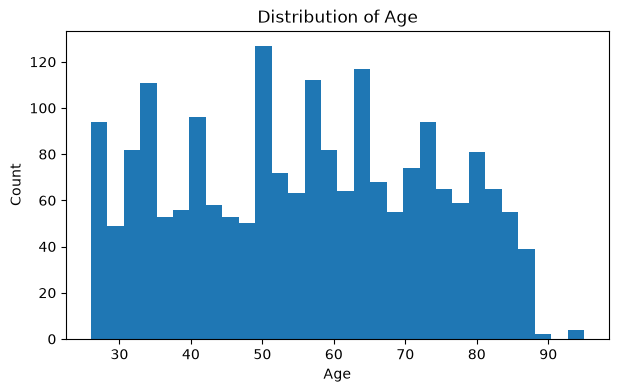

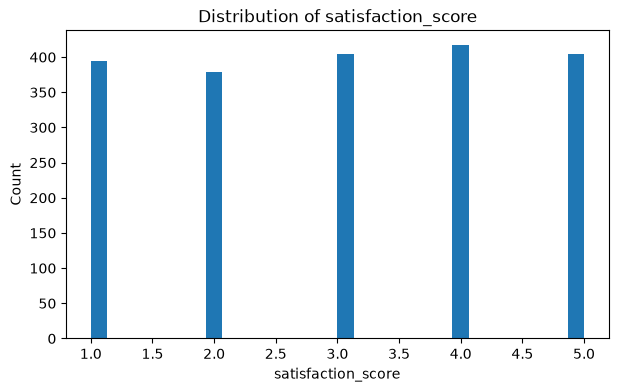

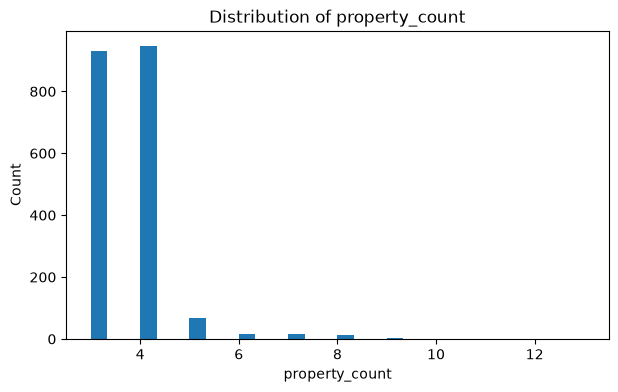

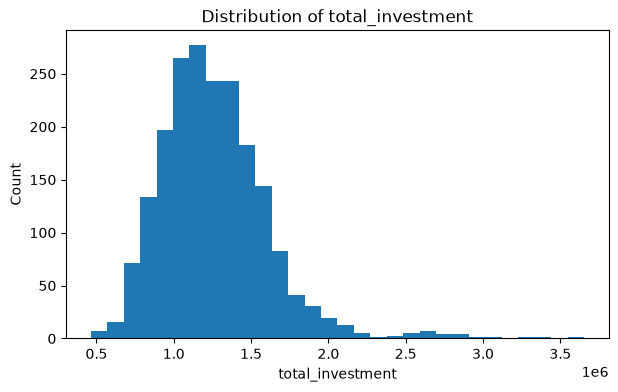

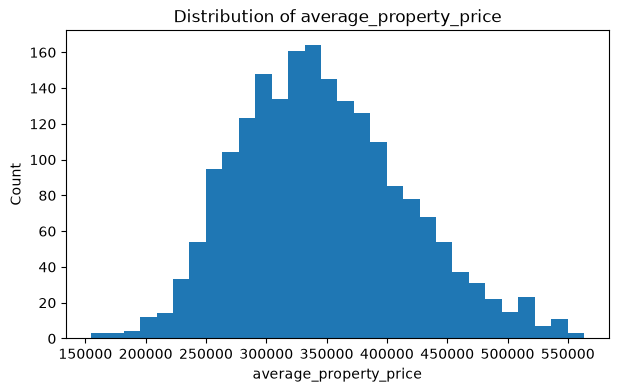

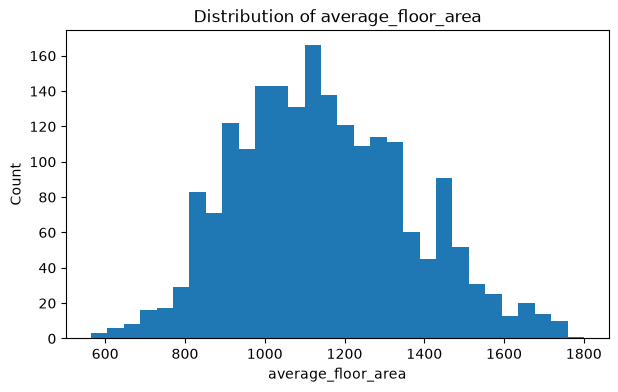

In [46]:
import matplotlib.pyplot as plt

numerical_cols = [
    'Age',
    'satisfaction_score',
    'property_count',
    'total_investment',
    'average_property_price',
    'average_floor_area'
]

for col in numerical_cols:
    plt.figure(figsize=(7,4))
    plt.hist(final_data[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

C:\Users\KIIT\AppData\Local\Temp\ipykernel_8768\534081964.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(final_data[col], vert=False)


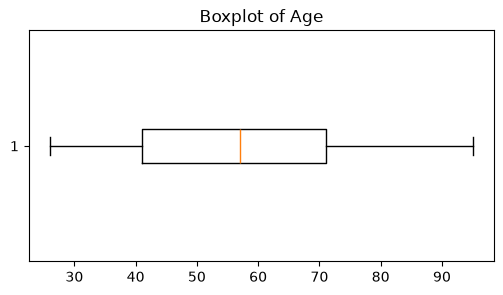

C:\Users\KIIT\AppData\Local\Temp\ipykernel_8768\534081964.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(final_data[col], vert=False)


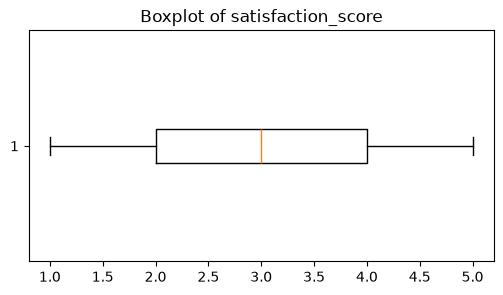

C:\Users\KIIT\AppData\Local\Temp\ipykernel_8768\534081964.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(final_data[col], vert=False)


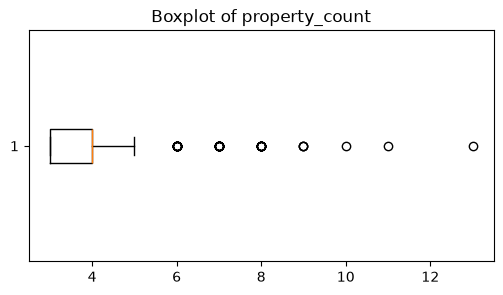

C:\Users\KIIT\AppData\Local\Temp\ipykernel_8768\534081964.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(final_data[col], vert=False)


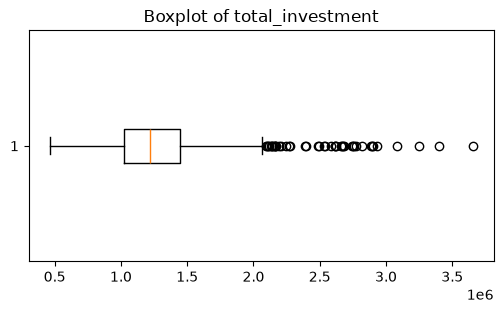

C:\Users\KIIT\AppData\Local\Temp\ipykernel_8768\534081964.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(final_data[col], vert=False)


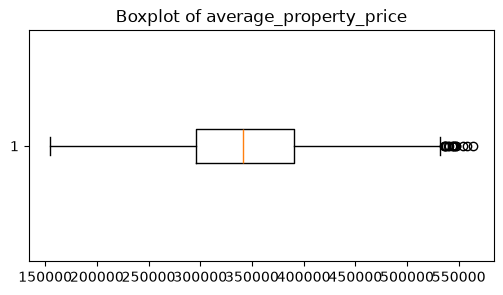

C:\Users\KIIT\AppData\Local\Temp\ipykernel_8768\534081964.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(final_data[col], vert=False)


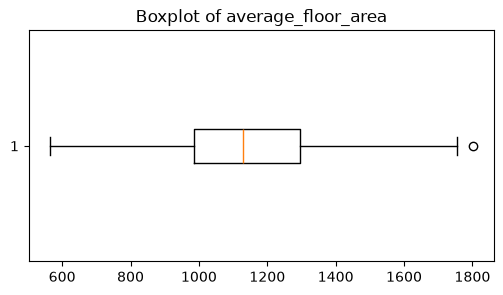

In [47]:
for col in numerical_cols:
    plt.figure(figsize=(6,3))
    plt.boxplot(final_data[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.show()

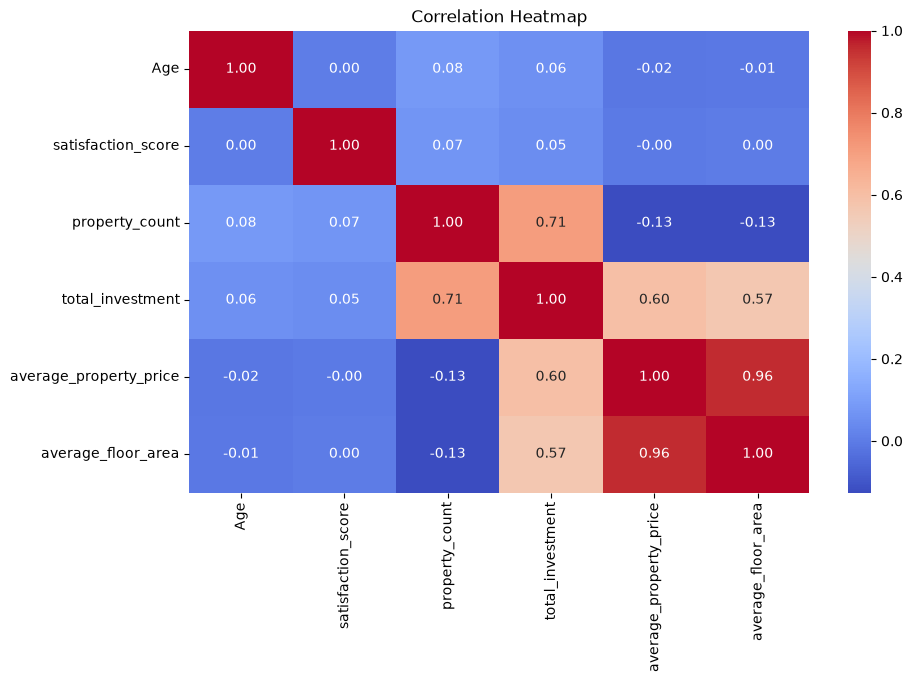

In [48]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    final_data[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

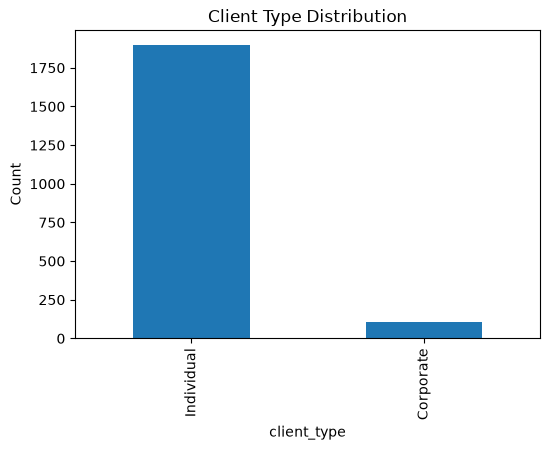

In [49]:
final_data['client_type'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Client Type Distribution")
plt.ylabel("Count")
plt.show()

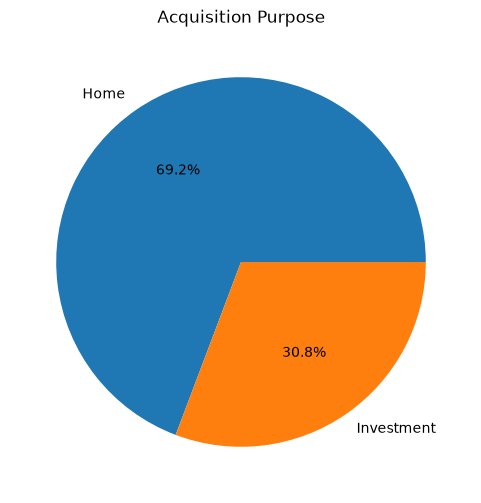

In [50]:
final_data['acquisition_purpose'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Acquisition Purpose")
plt.show()

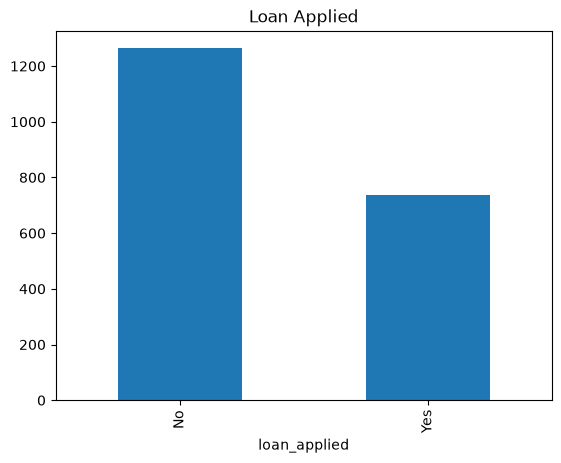

In [51]:
final_data['loan_applied'].value_counts().plot(
    kind='bar'
)

plt.title("Loan Applied")
plt.show()

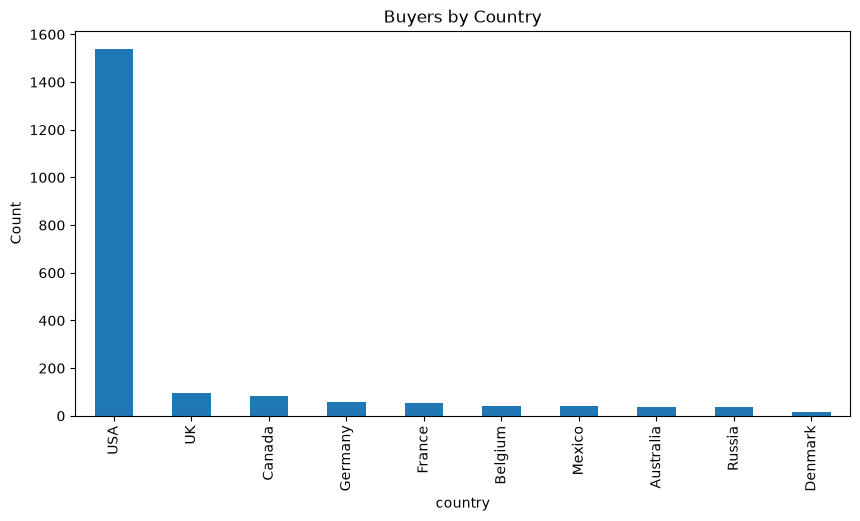

In [52]:
plt.figure(figsize=(10,5))

final_data['country'].value_counts().plot(kind='bar')

plt.title("Buyers by Country")
plt.ylabel("Count")
plt.show()

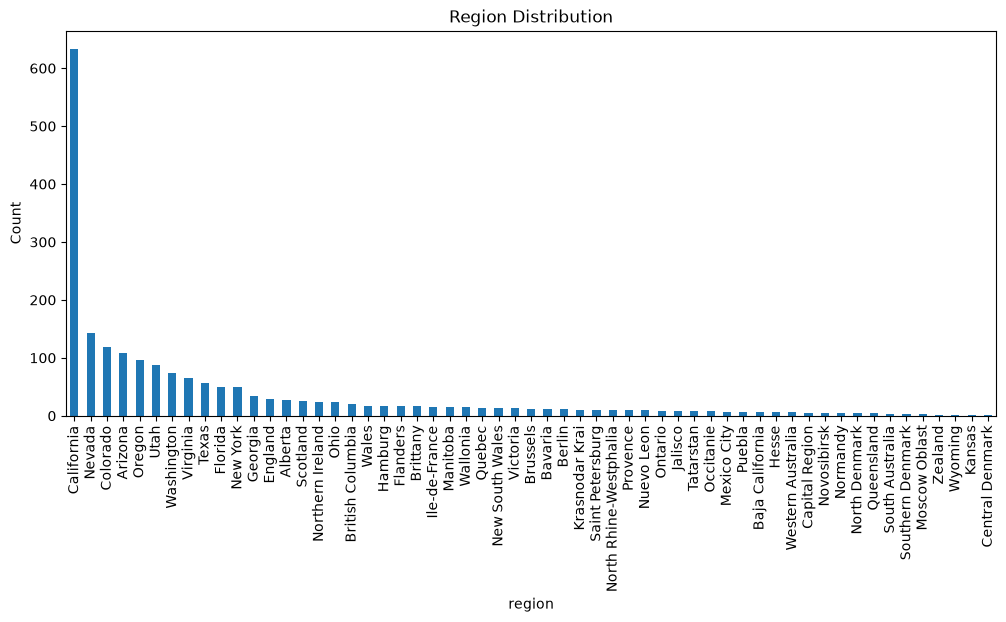

In [53]:
plt.figure(figsize=(12,5))

final_data['region'].value_counts().plot(kind='bar')

plt.title("Region Distribution")
plt.ylabel("Count")
plt.show()

# Data Clustering

In [69]:
cluster_features = final_data[
    [
        'Age',
        'satisfaction_score',
        'property_count',
        'total_investment',
        'average_property_price',
        'average_floor_area'
    ]
].copy()

In [70]:
categorical = final_data[
    [
        'client_type',
        'loan_applied',
        'acquisition_purpose'
    ]
]

categorical = pd.get_dummies(categorical, drop_first=True)

In [71]:
cluster_features = pd.concat(
    [cluster_features, categorical],
    axis=1
)

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_features)

In [73]:
from sklearn.cluster import KMeans

wcss = []

for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

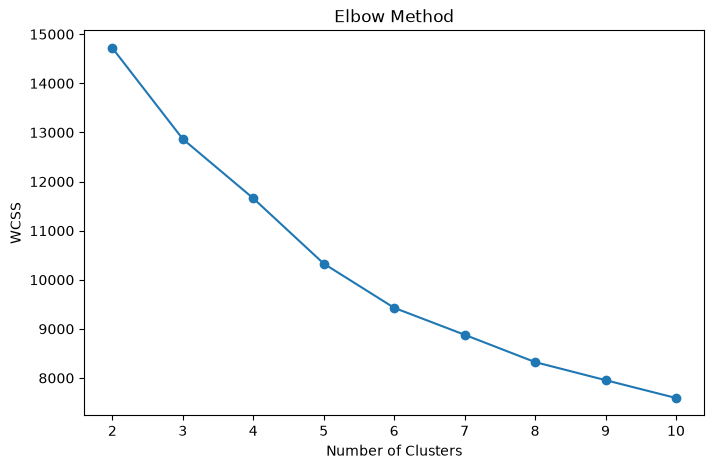

In [74]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [75]:
from sklearn.metrics import silhouette_score

for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    print(f"{i} Clusters : {score:.3f}")

2 Clusters : 0.177
3 Clusters : 0.198
4 Clusters : 0.178
5 Clusters : 0.193
6 Clusters : 0.187
7 Clusters : 0.190
8 Clusters : 0.178
9 Clusters : 0.169
10 Clusters : 0.175


In [76]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

final_data['Cluster'] = kmeans.fit_predict(scaled_data)

final_data.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,Age,property_count,total_investment,average_property_price,average_floor_area,Cluster
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,4,1246764.72,311691.180000,983.885000,2
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website,64,5,1841095.93,368219.186000,1187.942000,0
2,C0003,Individual,Kale,Gay,1959-04-07,M,USA,California,Home,4,Yes,Agency,67,5,1661457.59,332291.518000,1058.110000,0
3,C0004,Individual,Russell,Gross,1959-11-25,M,USA,California,Home,5,No,Website,67,6,1608263.51,268043.918333,937.103333,2
4,C0005,Corporate,Marleez,Co,1976-02-28,M,USA,California,Investment,5,No,Website,50,13,3653385.38,281029.644615,927.296154,3


In [85]:
final_data['Cluster'].value_counts()

Cluster
2    802
0    641
1    454
3    103
Name: count, dtype: int64

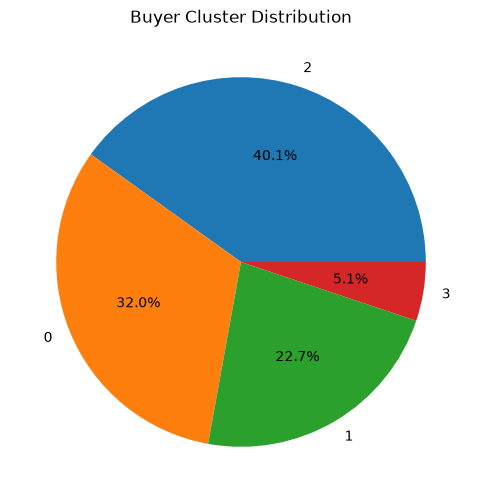

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

final_data['Cluster'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Buyer Cluster Distribution")

plt.show()

In [87]:
cluster_summary = final_data.groupby('Cluster')[[
    'Age',
    'satisfaction_score',
    'property_count',
    'total_investment',
    'average_property_price',
    'average_floor_area'
]].mean().round(2)

cluster_summary

,Age,satisfaction_score,property_count,total_investment,average_property_price,average_floor_area
Cluster,,,,,,
0,57.09,3.08,3.83,1574663.94,418885.19,1372.32
1,56.12,2.97,3.55,1126229.20,318758.64,1057.64
2,56.33,3.02,3.56,1084684.18,306032.44,1019.21
3,48.07,3.07,3.70,1263753.49,344854.97,1142.98


In [88]:
pd.crosstab(final_data['Cluster'], final_data['client_type'])

client_type,Corporate,Individual
Cluster,,
0,0,641
1,0,454
2,0,802
3,103,0


In [89]:
pd.crosstab(final_data['Cluster'], final_data['loan_applied'])

loan_applied,No,Yes
Cluster,,
0,416,225
1,280,174
2,508,294
3,60,43


In [90]:
pd.crosstab(final_data['Cluster'], final_data['acquisition_purpose'])

acquisition_purpose,Home,Investment
Cluster,,
0,516,125
1,0,454
2,802,0
3,67,36


In [93]:
final_data.to_csv("../data/final_data.csv", index=False)

In [91]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']